In [29]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import System
from syssimx.system.connection import EventConnection

In [30]:
import logging

logging.basicConfig(
    level=logging.WARNING,  # keep third-party loggers quiet
    format="[%(module)s] %(levelname)s: %(message)s",
)
# Enable debug output for the syssimx package
logging.getLogger("syssimx").setLevel(logging.DEBUG)

In [31]:
mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = np.rad2deg(0.3) # Initial angle

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 0.3
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 2e9

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'contact_params': contact_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
    'mesh_params': mesh_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")

pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

t = 0.0
dt = pendulum.fem.sim_params.tau
t_end = pendulum.fem.sim_params.t_end

In [32]:
def wall_contact_event_indicator(pendulum: MasterPendulum):
    theta_wall = 0
    theta_pendulum = pendulum.get_outputs()['theta']
    return theta_pendulum - theta_wall

pendulum.add_event_indicator(name="wall_hit",
                             func=wall_contact_event_indicator,
                             direction=-1)


In [33]:
system = System(name="PendulumSystem")

system.add_component(pendulum)

event_connection = EventConnection(
    src_comp=pendulum.name, src_port=pendulum.output_specs['wall_hit'].name,
    dst_comp=pendulum.name, dst_port=pendulum.input_specs['omega_invert'].name
)

system.add_event_connection(event_connection)

In [34]:
system._event_targets_by_source

{('MasterPendulum', 'wall_hit'): ['MasterPendulum']}

In [35]:
system.initialize(t0=0.0)

In [36]:
system.algorithm.record_internal_steps = False
system.algorithm.event_dedup_tol = 5e-4
system.algorithm.tol_time = 1e-5
system.algorithm.tol_value = 5e-5

In [37]:
system.run(t0=0.0, tf=sim_params.t_end, dt=sim_params.tau)

[system] INFO: Starting simulation run from t=0.0 to t=0.3 with dt=0.01
[multi_comp] INFO: [MasterPendulum] Switching: FMU to OpenSim @ t=0.0700s
[multi_comp] INFO: [MasterPendulum] Switching: OpenSim to FEM @ t=0.1900s
[hybrid] DEBUG: Internal hint: MasterPendulum.wall_hit in [0.23900000, 0.23910000]
[hybrid] INFO: ================================================================================
[hybrid] INFO: Event crossing in [0.230000, 0.240000]: MasterPendulum.wall_hit
[hybrid] DEBUG:   Internal hints from MasterPendulum: ['wall_hit']
[hybrid] DEBUG: Starting bisection for event localization ...
[hybrid] DEBUG: Narrowed interval via hint: [0.230000, 0.240000] -> [0.239000, 0.239100]
[hybrid] DEBUG: Indicators at left  (t=0.23900000): {'MasterPendulum': {'wall_hit': 2.037219337541667e-05}}
[hybrid] DEBUG: Indicators at right (t=0.23910000): {'MasterPendulum': {'wall_hit': -0.00017057119025650213}}
[hybrid] DEBUG: Bisection iteration 1: interval [0.23900000, 0.23910000]
[hybrid] DEBU

[FEM_Pendulum] Event 'wall_hit' at t=0.2390s.


[multi_comp] INFO: [MasterPendulum] Switching: FEM to OpenSim @ t=0.2800s
[system] INFO: Simulation completed in 127.45 seconds


In [46]:
# 7) Extract and plot results
history = system.get_history()
pendulum_history = history["MasterPendulum"]
event_history = history["Events"]

t_vals, data = pendulum_history
q_vals = data["theta"]
omega_vals = data["omega"]
alpha_vals = data["alpha"]

t_vals_fem, data_fem = pendulum.fem.get_history_arrays()
q_vals_fem = data_fem["theta"]
omega_vals_fem = data_fem["omega"]
t_vals_opensim, data_opensim = pendulum.opensim.get_history_arrays()
q_vals_opensim = data_opensim["theta"]
omega_vals_opensim = data_opensim["omega"]
t_vals_fmu, data_fmu = pendulum.fmu.get_history_arrays()
q_vals_fmu = data_fmu["theta"]
omega_vals_fmu = data_fmu["omega"]

# Get event times
event_times = event_history.get(("MasterPendulum", "wall_hit"), [])
t_event = event_times[0] if event_times else None

print(f"\nDetected {len(event_times)} events")
if t_event:
    print(f"First event at t = {t_event.t:.8f} s")


Detected 1 events
First event at t = 0.23902500 s


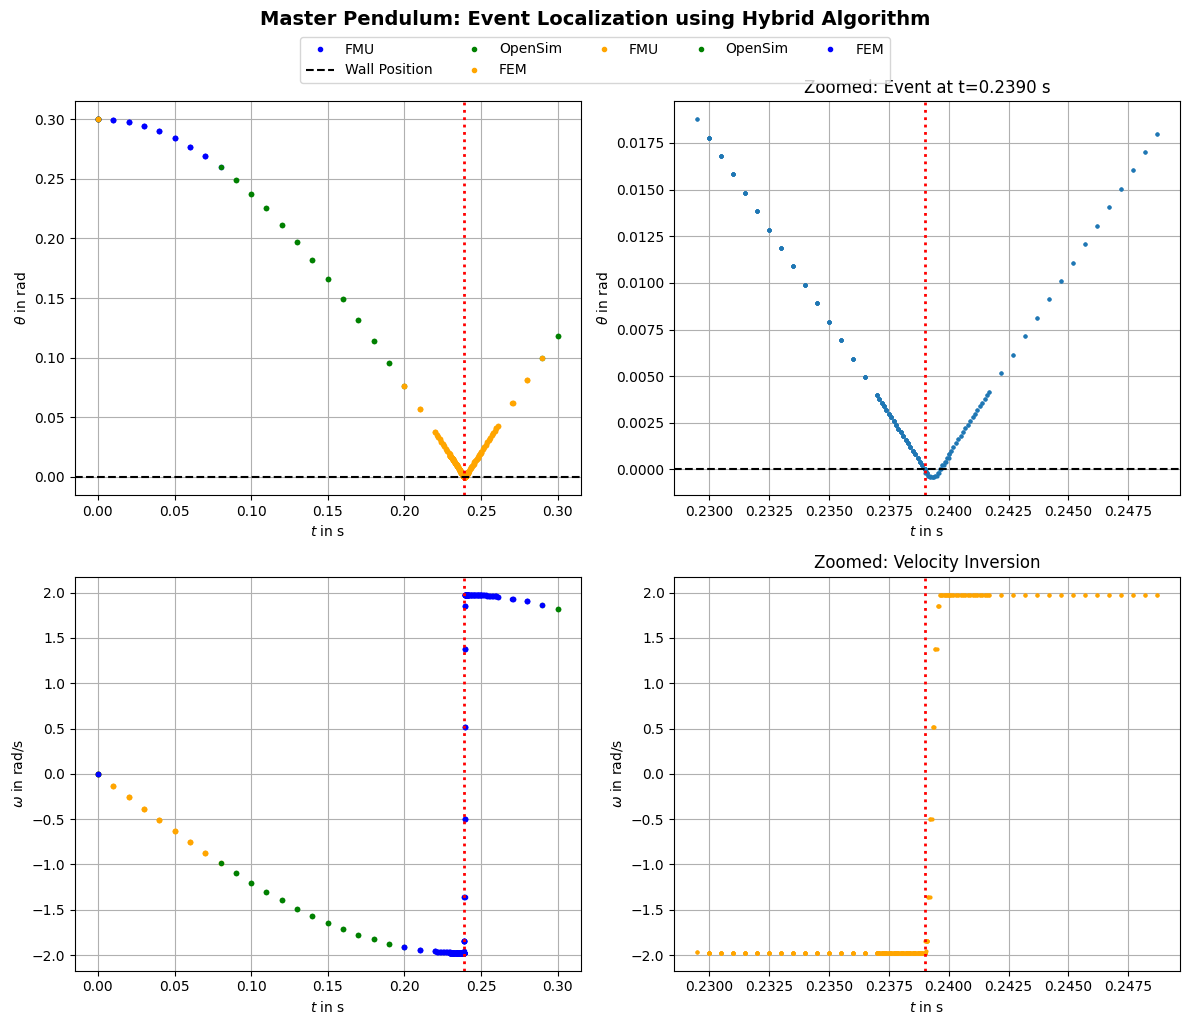

In [48]:
# 8) Visualization
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    "Master Pendulum: Event Localization using Hybrid Algorithm",
    fontweight="bold",
    fontsize=14,
    y=1.02,
)

# Top left: Full angle trajectory
(line1,) = axs[0, 0].plot(
    t_vals_fmu, q_vals_fmu, marker="o", color="blue", markersize=3, linestyle="None", label="FMU"
)
(line2,) = axs[0, 0].plot(
    t_vals_opensim, q_vals_opensim, marker="o", markersize=3, linestyle="None", color="green", label="OpenSim"
)
(line3, ) = axs[0, 0].plot(
    t_vals_fem, q_vals_fem, marker="o", markersize=3, linestyle="None", color="orange", label="FEM"
)
line4= axs[0, 0].axhline(0, color="k", linestyle="--", label="Wall Position")
if t_event:
    line5 = axs[0, 0].axvline(
        t_event.t, color="red", linestyle=":", linewidth=2, label="Event Time"
    )
axs[0, 0].set_xlabel(r"$t$ in $\mathrm{s}$")
axs[0, 0].set_ylabel(r"$\theta$ in $\mathrm{rad}$")
axs[0, 0].grid()

# Top right: Zoomed angle near event
if t_event:
    zoom_window = 0.01
    mask = (t_vals_fem >= t_event.t - zoom_window) & (t_vals_fem <= t_event.t + zoom_window)
    axs[0, 1].plot(t_vals_fem[mask], q_vals_fem[mask], "o", markersize=2)
    axs[0, 1].axhline(0, color="k", linestyle="--")
    axs[0, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[0, 1].set_xlabel(r"$t$ in $\mathrm{s}$")
    axs[0, 1].set_ylabel(r"$\theta$ in $\mathrm{rad}$")
    axs[0, 1].set_title(f"Zoomed: Event at t={t_event.t:.4f} s")
    axs[0, 1].grid()

# Bottom left: Full angular velocity
(line6,) = axs[1, 0].plot(
    t_vals_fmu, omega_vals_fmu, "o",color="orange", label=r"FMU", markersize=3
)
(line7,) = axs[1, 0].plot(
    t_vals_opensim, omega_vals_opensim, "o",color="green", label=r"OpenSim", markersize=3
)
(line8,) = axs[1, 0].plot(
    t_vals_fem, omega_vals_fem, "o",color="blue", label=r"FEM", markersize=3
)

if t_event:
    axs[1, 0].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
axs[1, 0].set_xlabel(r"$t$ in $\mathrm{s}$")
axs[1, 0].set_ylabel(r"$\omega$ in $\mathrm{rad/s}$")
axs[1, 0].grid()

# Bottom right: Zoomed velocity near event
if t_event:
    axs[1, 1].plot(t_vals_fem[mask], omega_vals_fem[mask], "o", color="orange", markersize=2)
    axs[1, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[1, 1].set_xlabel(r"$t$ in $\mathrm{s}$")
    axs[1, 1].set_ylabel(r"$\omega$ in $\mathrm{rad/s}$")
    axs[1, 1].set_title("Zoomed: Velocity Inversion")
    axs[1, 1].grid()

signals = [line1, line4, line2, line3, line6, line7, line8]  # , line5]
labels = [s.get_label() for s in signals if s is not None]
fig.legend(signals, labels, loc="upper center", bbox_to_anchor=(0.5, 1), ncol=5)

plt.tight_layout()
plt.show()